# 2호선 혼잡도 예측 - LSTM v6 (로그변환 + 피크가중치 + 역규모피처)

## 1. 라이브러리 임포트

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import joblib, json

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout,
                                     Embedding, Flatten, Concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import tensorflow as tf

## 2. 데이터 로드

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
line2 = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/project_weather/final_dataset_230101-241231.csv',
    encoding='utf-8-sig'
)
line2.head()

,날짜,역명,호선,승차인원,시간,하차인원,요일,월,공휴일여부,기온,강수량,적설
0,2023-01-01,시청,2호선,43,5,36,6,1,1,0.8,0.0,0.0
1,2023-01-01,을지로입구,2호선,108,5,114,6,1,1,0.8,0.0,0.0
2,2023-01-01,을지로3가,2호선,52,5,55,6,1,1,0.8,0.0,0.0
3,2023-01-01,을지로4가,2호선,21,5,37,6,1,1,0.8,0.0,0.0
4,2023-01-01,동대문역사문화공원(DDP),2호선,63,5,49,6,1,1,0.8,0.0,0.0


## 3. 전처리

> **수정 포인트**
> - 로그 변환을 스케일링 전에 적용 (`np.log1p`)
> - 역별 평균 승하차 규모 피처 추가 (`역별_평균_승차`, `역별_평균_하차`)
> - 역명_enc는 Embedding 레이어 전용 (스케일링 제외)

In [ ]:
# 정렬 및 불필요 컬럼 제거
line2 = line2.sort_values(['역명', '날짜', '시간']).reset_index(drop=True)
line2.drop(columns=['호선'], inplace=True)

# 역명 인코딩 (Embedding 입력용, 스케일링 제외)
le = LabelEncoder()
line2['역명_enc'] = le.fit_transform(line2['역명'])
n_stations = line2['역명_enc'].nunique()
print(f"역 수: {n_stations}")

# 요일×시간 interaction 피처
line2['요일_시간'] = line2['요일'] * 24 + line2['시간']

# 역별 평균 승하차 규모 피처 (로그 변환 전 원본 기준)
line2['역별_평균_승차'] = line2.groupby('역명')['승차인원'].transform('mean')
line2['역별_평균_하차'] = line2.groupby('역명')['하차인원'].transform('mean')

# ── 로그 변환 (스케일링 전) ──────────────────────────────────
line2['승차인원']       = np.log1p(line2['승차인원'])
line2['하차인원']       = np.log1p(line2['하차인원'])
line2['역별_평균_승차'] = np.log1p(line2['역별_평균_승차'])
line2['역별_평균_하차'] = np.log1p(line2['역별_평균_하차'])
print("로그 변환 완료")
print(f"승차인원 max: {line2['승차인원'].max():.4f} (log1p({int(np.expm1(line2['승차인원'].max()))}명))")

# 스케일링 피처 (역명_enc 제외)
numeric_features = [
    '승차인원',        # index 0 (target)
    '하차인원',        # index 1 (target)
    '시간',
    '요일',
    '월',
    '공휴일여부',
    '기온',
    '강수량',
    '적설',
    '요일_시간',
    '역별_평균_승차',
    '역별_평균_하차'
]

scaler = MinMaxScaler()
line2[numeric_features] = scaler.fit_transform(line2[numeric_features])

features = numeric_features
print(f"총 피처 수: {len(features)}")
line2.head()

역 수: 50
로그 변환 완료
승차인원 max: 9.8505 (log1p(18966명))
총 피처 수: 12


,날짜,역명,승차인원,시간,하차인원,요일,월,공휴일여부,기온,강수량,적설,역명_enc,요일_시간,역별_평균_승차,역별_평균_하차
0,2023-01-01,강남,0.702874,0.217391,0.486912,1.0,0.0,1.0,0.336449,0.0,0.0,0,0.892216,0.993405,0.990113
1,2023-01-01,강남,0.691688,0.260870,0.628247,1.0,0.0,1.0,0.317757,0.0,0.0,0,0.898204,0.993405,0.990113
2,2023-01-01,강남,0.648213,0.304348,0.615534,1.0,0.0,1.0,0.293458,0.0,0.0,0,0.904192,0.993405,0.990113
3,2023-01-01,강남,0.632307,0.347826,0.655377,1.0,0.0,1.0,0.287850,0.0,0.0,0,0.910180,0.993405,0.990113
4,2023-01-01,강남,0.647008,0.391304,0.709612,1.0,0.0,1.0,0.289720,0.0,0.0,0,0.916168,0.993405,0.990113


## 4. 시퀀스 데이터 생성

> **수정 포인트**
> - `SEQUENCE_LENGTH = 5` (20 → 5) : 긴 시퀀스가 피크를 smoothing하는 문제 해결
> - 역명_enc를 X_station으로 분리 저장

In [ ]:
SEQUENCE_LENGTH = 12

X, X_station, y_boarding, y_alighting, metadata_list = [], [], [], [], []

for station in line2['역명'].unique():
    station_data = line2[line2['역명'] == station].reset_index(drop=True)
    values       = station_data[features].values
    station_enc  = station_data['역명_enc'].values

    for i in range(len(values) - SEQUENCE_LENGTH):
        X.append(values[i : i + SEQUENCE_LENGTH])
        X_station.append(station_enc[i])
        y_boarding.append(values[i + SEQUENCE_LENGTH][0])
        y_alighting.append(values[i + SEQUENCE_LENGTH][1])

        target_row = station_data.loc[i + SEQUENCE_LENGTH]
        metadata_list.append({
            '날짜': target_row['날짜'],
            '역명': target_row['역명'],
            '시간': target_row['시간']
        })

X           = np.array(X)
X_station   = np.array(X_station)
y_boarding  = np.array(y_boarding)
y_alighting = np.array(y_alighting)
metadata_df = pd.DataFrame(metadata_list)

print(f"X shape:          {X.shape}")
print(f"X_station shape:  {X_station.shape}")
print(f"y_boarding shape: {y_boarding.shape}")

X shape:          (730400, 12, 12)
X_station shape:  (730400,)
y_boarding shape: (730400,)


## 5. 학습 / 테스트 분리 (역별 시간 기준 80/20)

In [ ]:
train_indices = []
test_indices  = []

for station in metadata_df['역명'].unique():
    idx = metadata_df[metadata_df['역명'] == station].index.tolist()
    split = int(len(idx) * 0.8)
    train_indices.extend(idx[:split])
    test_indices.extend(idx[split:])

X_train         = X[train_indices]
X_test          = X[test_indices]
X_station_train = X_station[train_indices]
X_station_test  = X_station[test_indices]
y_boarding_train  = y_boarding[train_indices]
y_boarding_test   = y_boarding[test_indices]
y_alighting_train = y_alighting[train_indices]
y_alighting_test  = y_alighting[test_indices]
metadata_train = metadata_df.loc[train_indices].reset_index(drop=True)
metadata_test  = metadata_df.loc[test_indices].reset_index(drop=True)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Test 시작 날짜: {metadata_test['날짜'].min()}")
print(f"Test 종료 날짜: {metadata_test['날짜'].max()}")
print(f"Test 역 수: {metadata_test['역명'].nunique()}")

Train: (584300, 12, 12), Test: (146100, 12, 12)
Test 시작 날짜: 2024-08-07
Test 종료 날짜: 2025-01-01
Test 역 수: 50


## 6. 피크 시간대 샘플 가중치 생성

> 출퇴근 피크 시간대(07~09시, 18~20시) 가중치 2.0배 적용

In [ ]:
# 스케일된 시간값 → 실제 시간 복원
time_col_idx = numeric_features.index('시간')
dummy_time   = np.zeros((len(X_train), len(numeric_features)))
dummy_time[:, time_col_idx] = X_train[:, -1, time_col_idx]
real_hours = scaler.inverse_transform(dummy_time)[:, time_col_idx]

# 피크 시간대 마스킹
is_peak = (
    ((real_hours >= 7)  & (real_hours <= 9)) |
    ((real_hours >= 18) & (real_hours <= 20))
)
sample_weights = np.where(is_peak, 2.0, 1.0)

print(f"피크 샘플 수: {is_peak.sum():,} / 전체: {len(is_peak):,} ({is_peak.mean()*100:.1f}%)")

피크 샘플 수: 175,350 / 전체: 584,300 (30.0%)


## 7. LSTM 모델 정의 (Embedding 포함)

> - 시계열(LSTM) + 역명(Embedding) 두 브랜치 Concatenate
> - L2 정규화 + Dropout으로 과적합 방지

In [ ]:
EMBEDDING_DIM = 8

def build_model(n_stations, seq_len, n_features, embedding_dim=EMBEDDING_DIM):
    input_seq     = Input(shape=(seq_len, n_features), name='sequence_input')
    input_station = Input(shape=(1,), name='station_input')

    # LSTM 브랜치
    x = LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001))(input_seq)
    x = Dropout(0.3)(x)
    x = LSTM(32, kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.3)(x)

    # Embedding 브랜치
    emb = Embedding(input_dim=n_stations, output_dim=embedding_dim,
                    name='station_embedding')(input_station)
    emb = Flatten()(emb)

    # 합치기
    merged = Concatenate()([x, emb])
    merged = Dense(32, activation='relu', kernel_regularizer=l2(0.001))(merged)
    merged = Dropout(0.2)(merged)
    out    = Dense(1)(merged)

    return Model(inputs=[input_seq, input_station], outputs=out)

model_boarding  = build_model(n_stations, SEQUENCE_LENGTH, len(features))
model_alighting = build_model(n_stations, SEQUENCE_LENGTH, len(features))

model_boarding.compile(optimizer=Adam(learning_rate=0.0005),  loss='mse', metrics=['mae'])
model_alighting.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])

model_boarding.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 12, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 12, 64)    │     19,712 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 12, 64)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ station_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ station_embedding   │ (None, 1, 8)      │        400 │ station_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8)         │          0 │ station_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 40)        │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      1,312 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,873 (132.32 KB)

 Trainable params: 33,873 (132.32 KB)

 Non-trainable params: 0 (0.00 B)

## 8. 모델 학습

> - 승차/하차 각각 별도 콜백 사용 (콜백 상태 공유 방지)
> - 피크 시간대 `sample_weight` 적용

In [ ]:
# 승차 콜백
early_stop_boarding = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr_boarding  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                                         min_lr=0.00001, verbose=1)
# 하차 콜백
early_stop_alighting = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr_alighting  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                                          min_lr=0.00001, verbose=1)

print("=" * 40)
print("승차 모델 학습")
print("=" * 40)
history_boarding = model_boarding.fit(
    [X_train, X_station_train], y_boarding_train,
    sample_weight=sample_weights,
    epochs=100,
    batch_size=1024,
    validation_split=0.2,
    callbacks=[early_stop_boarding, reduce_lr_boarding],
    verbose=1
)

print("=" * 40)
print("하차 모델 학습")
print("=" * 40)
history_alighting = model_alighting.fit(
    [X_train, X_station_train], y_alighting_train,
    sample_weight=sample_weights,
    epochs=100,
    batch_size=1024,
    validation_split=0.2,
    callbacks=[early_stop_alighting, reduce_lr_alighting],
    verbose=1
)

승차 모델 학습
Epoch 1/100
457/457 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.1436 - mae: 0.1580 - val_loss: 0.0744 - val_mae: 0.1286 - learning_rate: 5.0000e-04
Epoch 2/100
457/457 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0519 - mae: 0.0974 - val_loss: 0.0672 - val_mae: 0.1724 - learning_rate: 5.0000e-04
Epoch 3/100
457/457 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0323 - mae: 0.0841 - val_loss: 0.0519 - val_mae: 0.1607 - learning_rate: 5.0000e-04
Epoch 4/100
457/457 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0229 - mae: 0.0769 - val_loss: 0.0367 - val_mae: 0.1341 - learning_rate: 5.0000e-04
Epoch 5/100
457/457 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0173 - mae: 0.0706 - val_loss: 0.0297 - val_mae: 0.1212 - learning_rate: 5.0000e-04
Epoch 6/100
457/457 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0136 - mae: 0.0645 - val_loss: 0.0208 - val_mae: 0.0955 - learning_rate: 5.0000e-04
Epoch 7/100
457/457 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0111 - mae: 0.0590 - val_loss: 0.0173 

## 9. 예측 및 역정규화

> scaler 역변환 → log1p 역변환(`np.expm1`) 순서로 복원

## 8-2. 잠실역 전용 모델 학습

> 잠실역은 max 12,844명으로 전체 평균(1,300명)의 10배 수준  
> 단일 모델로는 고값 억제 한계 → 전용 모델 별도 학습

In [ ]:
# 잠실역 데이터만 분리
잠실_mask_train = metadata_train['역명'] == '잠실(송파구청)'
잠실_mask_test  = metadata_test['역명']  == '잠실(송파구청)'

X_잠실_train         = X_train[잠실_mask_train]
X_station_잠실_train = X_station_train[잠실_mask_train]
y_boarding_잠실_train  = y_boarding_train[잠실_mask_train]
y_alighting_잠실_train = y_alighting_train[잠실_mask_train]
sample_weights_잠실    = sample_weights[잠실_mask_train]

X_잠실_test         = X_test[잠실_mask_test]
X_station_잠실_test = X_station_test[잠실_mask_test]
y_boarding_잠실_test  = y_boarding_test[잠실_mask_test]
y_alighting_잠실_test = y_alighting_test[잠실_mask_test]

print(f"잠실 train: {X_잠실_train.shape}, test: {X_잠실_test.shape}")

잠실_enc = le.transform(['잠실(송파구청)'])[0]

model_boarding_잠실  = build_model(n_stations, SEQUENCE_LENGTH, len(features))
model_alighting_잠실 = build_model(n_stations, SEQUENCE_LENGTH, len(features))
model_boarding_잠실.compile(optimizer=Adam(learning_rate=0.0005),  loss='mse', metrics=['mae'])
model_alighting_잠실.compile(optimizer=Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])

early_stop_잠실_b = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr_잠실_b  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7,
                                       min_lr=0.00001, verbose=1)
early_stop_잠실_a = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr_잠실_a  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7,
                                       min_lr=0.00001, verbose=1)

print("=" * 40)
print("잠실 승차 모델 학습")
print("=" * 40)
history_잠실_boarding = model_boarding_잠실.fit(
    [X_잠실_train, X_station_잠실_train], y_boarding_잠실_train,
    sample_weight=sample_weights_잠실,
    epochs=1000,        # 300 → 500
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop_잠실_b, reduce_lr_잠실_b],
    verbose=1
)

print("=" * 40)
print("잠실 하차 모델 학습")
print("=" * 40)
history_잠실_alighting = model_alighting_잠실.fit(
    [X_잠실_train, X_station_잠실_train], y_alighting_잠실_train,
    sample_weight=sample_weights_잠실,
    epochs=1000,        # 300 → 500
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop_잠실_a, reduce_lr_잠실_a],
    verbose=1
)

print(f"\n승차 최종 epoch: {len(history_잠실_boarding.history['loss'])}")
print(f"승차 최종 val_loss: {min(history_잠실_boarding.history['val_loss']):.6f}")
print(f"하차 최종 epoch: {len(history_잠실_alighting.history['loss'])}")
print(f"하차 최종 val_loss: {min(history_잠실_alighting.history['val_loss']):.6f}")

잠실 train: (11686, 12, 12), test: (2922, 12, 12)
잠실 승차 모델 학습
Epoch 1/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.3197 - mae: 0.2964 - val_loss: 0.1722 - val_mae: 0.1552 - learning_rate: 5.0000e-04
Epoch 2/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1961 - mae: 0.1849 - val_loss: 0.1421 - val_mae: 0.1067 - learning_rate: 5.0000e-04
Epoch 3/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1714 - mae: 0.1671 - val_loss: 0.1275 - val_mae: 0.0947 - learning_rate: 5.0000e-04
Epoch 4/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1511 - mae: 0.1530 - val_loss: 0.1169 - val_mae: 0.0961 - learning_rate: 5.0000e-04
Epoch 5/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1386 - mae: 0.1475 - val_loss: 0.1062 - val_mae: 0.0878 - learning_rate: 5.0000e-04
Epoch 6/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1249 - mae: 0.1388 - val_loss: 0.1001 - val_mae: 0.0981 - learning_rate: 5.0000e-04
Epoch 7/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - los

In [ ]:
n_pad = len(numeric_features) - 2  # 승차·하차 제외 나머지

def inverse_target(arr, scaler, col_idx, n_pad):
    """스케일 역변환 + 로그 역변환 (col_idx: 0=승차, 1=하차)"""
    arr = arr.reshape(-1, 1)
    if col_idx == 0:
        padded = np.concatenate([arr, np.zeros((len(arr), n_pad + 1))], axis=1)
    else:
        padded = np.concatenate([np.zeros((len(arr), 1)), arr,
                                 np.zeros((len(arr), n_pad))], axis=1)
    result = scaler.inverse_transform(padded)[:, col_idx]
    return np.expm1(result)  # log1p 역변환

pred_boarding  = model_boarding.predict([X_test, X_station_test]).flatten()
pred_alighting = model_alighting.predict([X_test, X_station_test]).flatten()

pred_boarding_real  = inverse_target(pred_boarding,    scaler, 0, n_pad)
pred_alighting_real = inverse_target(pred_alighting,   scaler, 1, n_pad)
y_boarding_real     = inverse_target(y_boarding_test,  scaler, 0, n_pad)
y_alighting_real    = inverse_target(y_alighting_test, scaler, 1, n_pad)

4566/4566 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step
4566/4566 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step


## 10. 결과 DataFrame 생성

In [ ]:
# 전체 예측 (잠실역 제외)
비잠실_mask_test = metadata_test['역명'] != '잠실(송파구청)'

pred_boarding_all  = np.zeros(len(X_test))
pred_alighting_all = np.zeros(len(X_test))

# 일반 모델 예측
pred_boarding_all[비잠실_mask_test]  = model_boarding.predict(
    [X_test[비잠실_mask_test], X_station_test[비잠실_mask_test]], verbose=0).flatten()
pred_alighting_all[비잠실_mask_test] = model_alighting.predict(
    [X_test[비잠실_mask_test], X_station_test[비잠실_mask_test]], verbose=0).flatten()

# 잠실 전용 모델 예측
pred_boarding_all[잠실_mask_test]  = model_boarding_잠실.predict(
    [X_잠실_test, X_station_잠실_test], verbose=0).flatten()
pred_alighting_all[잠실_mask_test] = model_alighting_잠실.predict(
    [X_잠실_test, X_station_잠실_test], verbose=0).flatten()

# 역정규화
pred_boarding_real  = inverse_target(pred_boarding_all,   scaler, 0, n_pad)
pred_alighting_real = inverse_target(pred_alighting_all,  scaler, 1, n_pad)
y_boarding_real     = inverse_target(y_boarding_test,     scaler, 0, n_pad)
y_alighting_real    = inverse_target(y_alighting_test,    scaler, 1, n_pad)

In [ ]:
result = pd.DataFrame({
    '실제승차': y_boarding_real,
    '예측승차': pred_boarding_real,
    '실제하차': y_alighting_real,
    '예측하차': pred_alighting_real
})
result = pd.concat([metadata_test.reset_index(drop=True), result], axis=1)
result['날짜'] = pd.to_datetime(result['날짜'])

result.head(20)

,날짜,역명,시간,실제승차,예측승차,실제하차,예측하차
0,2024-08-07,강남,1.000000,2436.0,2179.062588,651.0,1501.691412
1,2024-08-08,강남,0.000000,494.0,779.866039,247.0,489.286194
2,2024-08-08,강남,0.217391,258.0,551.659141,471.0,358.565363
3,2024-08-08,강남,0.260870,637.0,1369.191921,2388.0,2095.214741
4,2024-08-08,강남,0.304348,1500.0,2227.481870,7188.0,5769.011283
5,2024-08-08,강남,0.347826,2901.0,2635.808776,14067.0,16207.892158
6,2024-08-08,강남,0.391304,2202.0,2419.505891,13140.0,12609.898718
7,2024-08-08,강남,0.434783,1953.0,2149.678091,6170.0,6301.806794
8,2024-08-08,강남,0.478261,2451.0,2152.935883,3703.0,4406.110399
9,2024-08-08,강남,0.521739,2982.0,2505.531231,3305.0,4267.101043


## 11. 평가 지표

In [ ]:
def print_metrics(label, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"[{label}]  MAE: {mae:.2f}  |  MSE: {mse:.2f}  |  RMSE: {rmse:.2f}")

print_metrics("승차", result['실제승차'], result['예측승차'])
print_metrics("하차", result['실제하차'], result['예측하차'])

# 고값 구간 억제 확인
print("\n=== 승차 3000명 이상 구간 ===")
high = result[result['실제승차'] >= 3000]
print(f"샘플 수: {len(high)}")
print(f"실제 평균: {high['실제승차'].mean():,.0f}  예측 평균: {high['예측승차'].mean():,.0f}")

print("\n=== 승차 5000명 이상 구간 ===")
very_high = result[result['실제승차'] >= 5000]
print(f"샘플 수: {len(very_high)}")
print(f"실제 평균: {very_high['실제승차'].mean():,.0f}  예측 평균: {very_high['예측승차'].mean():,.0f}")

[승차]  MAE: 394.30  |  MSE: 733669.13  |  RMSE: 856.54
[하차]  MAE: 379.73  |  MSE: 748420.50  |  RMSE: 865.11

=== 승차 3000명 이상 구간 ===
샘플 수: 15038
실제 평균: 5,232  예측 평균: 3,607

=== 승차 5000명 이상 구간 ===
샘플 수: 6254
실제 평균: 7,252  예측 평균: 4,602


## 12. 학습 곡선 시각화

/tmp/ipykernel_4888/673594135.py:19: UserWarning: Glyph 49849 (\N{HANGUL SYLLABLE SEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4888/673594135.py:19: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4888/673594135.py:19: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49849 (\N{HANGUL SYLLABLE SEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  fig.canvas.pri

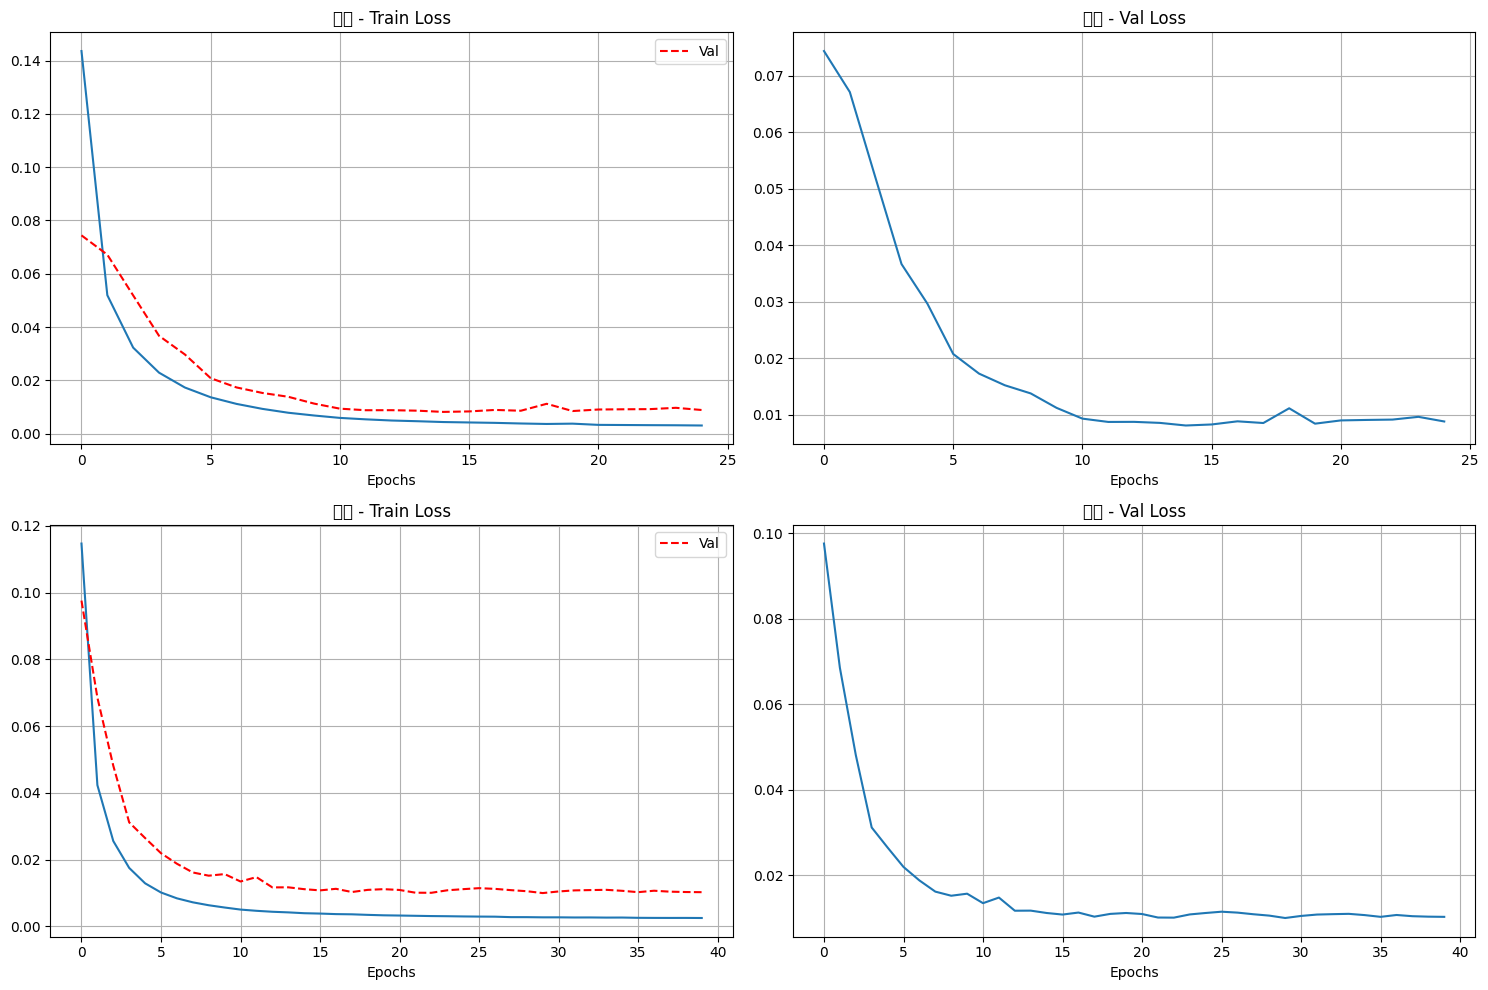

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, hist, title in [
    (axes[0][0], history_boarding.history['loss'],     '승차 - Train Loss'),
    (axes[0][1], history_boarding.history['val_loss'], '승차 - Val Loss'),
    (axes[1][0], history_alighting.history['loss'],    '하차 - Train Loss'),
    (axes[1][1], history_alighting.history['val_loss'],'하차 - Val Loss'),
]:
    ax.plot(hist)
    ax.set_title(title)
    ax.set_xlabel('Epochs')
    ax.grid()

axes[0][0].plot(history_boarding.history['val_loss'],  'r--', label='Val')
axes[0][0].legend()
axes[1][0].plot(history_alighting.history['val_loss'], 'r--', label='Val')
axes[1][0].legend()

plt.tight_layout()
plt.show()

## 13. 역별·날짜별 인터랙티브 시각화 (Plotly)

In [ ]:
def plot_station_day(station_name: str, date_str: str):
    date_dt  = pd.to_datetime(date_str)
    filtered = result[
        (result['역명'] == station_name) &
        (result['날짜'] == date_dt)
    ].sort_values('시간').copy()

    if filtered.empty:
        print(f"데이터 없음: {station_name} / {date_str}")
        return

    dummy = np.zeros((len(filtered), len(numeric_features)))
    dummy[:, 2] = filtered['시간'].values
    filtered['실제시간'] = scaler.inverse_transform(dummy)[:, 2].astype(int)
    print(f"시간 범위: {sorted(filtered['실제시간'].unique())}")

    plotly_config = {'displayModeBar': False}
    x_axis = dict(title='시간', tickmode='linear', tick0=5, dtick=1,
                  range=[5, 24], fixedrange=True)

    for target, real_col, pred_col in [
        ('승차', '실제승차', '예측승차'),
        ('하차', '실제하차', '예측하차')
    ]:
        fig = go.Figure([
            go.Scatter(x=filtered['실제시간'], y=filtered[real_col],
                       mode='lines+markers', name=f'실제{target}'),
            go.Scatter(x=filtered['실제시간'], y=filtered[pred_col],
                       mode='lines+markers', name=f'예측{target}'),
        ])
        fig.update_layout(
            title=f"{station_name}역 {target}인원 예측 ({date_str})",
            xaxis=x_axis,
            yaxis=dict(title=f'{target}인원', fixedrange=True),
            hovermode='x unified'
        )
        fig.show(config=plotly_config)

# 사용 예시
plot_station_day('강남', '2024-11-25')

시간 범위: [np.int64(0), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


## 14. 미래 예측

In [ ]:
def predict_future(station_name, date_str, hour, temp=None, rain=0, snow=0):
    """
    미래 시점 승차/하차 예측
    - 잠실(송파구청)역은 전용 모델 자동 사용
    """
    date_dt    = pd.to_datetime(date_str)
    month      = date_dt.month
    weekday    = date_dt.weekday()
    is_holiday = 0

    # 기온 자동 설정
    if temp is None:
        temp_idx   = numeric_features.index('기온')
        month_idx  = numeric_features.index('월')
        _tmp = np.zeros((1, len(numeric_features)))
        _tmp[0, month_idx] = month
        month_scaled_val = scaler.transform(_tmp)[0][month_idx]
        month_mask = np.abs(line2['월'] - month_scaled_val) < 0.01
        temp_scaled_mean = line2.loc[month_mask, '기온'].mean()
        dummy = np.zeros((1, len(numeric_features)))
        dummy[0, temp_idx] = temp_scaled_mean
        temp = scaler.inverse_transform(dummy)[0][temp_idx]
        print(f"기온 자동 설정: {temp:.1f}°C ({month}월 평균)")

    # 역별 평균 승하차
    station_mask      = line2['역명'] == station_name
    avg_boarding_log  = line2.loc[station_mask, '역별_평균_승차'].mean()
    avg_alighting_log = line2.loc[station_mask, '역별_평균_하차'].mean()

    input_row = np.array([[
        0, 0,
        hour, weekday, month,
        is_holiday, temp, rain, snow,
        weekday * 24 + hour,
        avg_boarding_log,
        avg_alighting_log
    ]])
    scaled_row = scaler.transform(input_row)

    station_enc = le.transform([station_name])[0]
    station_all = line2[line2['역명'] == station_name].copy().reset_index(drop=True)

    # 예측 시간 스케일값
    _tmp_h = np.zeros((1, len(numeric_features)))
    _tmp_h[0, numeric_features.index('시간')] = hour
    hour_scaled_val = scaler.transform(_tmp_h)[0][numeric_features.index('시간')]

    # 같은 시간대 행 전체 찾기
    same_hour_idx = station_all[
        np.abs(station_all['시간'] - hour_scaled_val) < 0.01
    ].index.tolist()

    if len(same_hour_idx) == 0:
        same_hour_idx = [np.abs(station_all['시간'] - hour_scaled_val).idxmin()]

    # 가장 최근 같은 시간대 행 직전 SEQUENCE_LENGTH개
    best_idx  = same_hour_idx[-1]
    start_idx = max(0, best_idx - SEQUENCE_LENGTH)
    seq_data  = station_all.iloc[start_idx:best_idx]

    if len(seq_data) < SEQUENCE_LENGTH:
        seq_data = station_all.iloc[best_idx:best_idx + SEQUENCE_LENGTH]

    seq = seq_data.tail(SEQUENCE_LENGTH)[features].values.copy()
    seq[-1] = scaled_row[0]

    X_pred         = seq.reshape(1, SEQUENCE_LENGTH, len(features)).astype(np.float32)
    X_station_pred = np.array([station_enc]).reshape(1, 1).astype(np.int32)

    # 잠실역 전용 모델 분기
    if station_name == '잠실(송파구청)':
        pred_b = model_boarding_잠실.predict([X_pred, X_station_pred], verbose=0).flatten()
        pred_a = model_alighting_잠실.predict([X_pred, X_station_pred], verbose=0).flatten()
    else:
        pred_b = model_boarding.predict([X_pred, X_station_pred], verbose=0).flatten()
        pred_a = model_alighting.predict([X_pred, X_station_pred], verbose=0).flatten()

    boarding_pred  = inverse_target(pred_b, scaler, 0, n_pad)[0]
    alighting_pred = inverse_target(pred_a, scaler, 1, n_pad)[0]

    print(f"\n{'='*40}")
    print(f"역명  : {station_name}")
    print(f"날짜  : {date_str}  {hour}시")
    print(f"요일  : {['월','화','수','목','금','토','일'][weekday]}요일")
    print(f"기온  : {temp:.1f}°C  강수량: {rain}mm  적설: 0cm")
    print(f"{'='*40}")
    print(f"예측 승차인원 : {boarding_pred:,.0f} 명")
    print(f"예측 하차인원 : {alighting_pred:,.0f} 명")
    print(f"{'='*40}")

    return boarding_pred, alighting_pred

# 사용 예시
predict_future('강남', '2026-12-25', 20)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but MinMaxScaler was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but MinMaxScaler was fitted with feature names



기온 자동 설정: 1.3°C (12월 평균)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but MinMaxScaler was fitted with feature names




역명  : 강남
날짜  : 2026-12-25  20시
요일  : 금요일
기온  : 1.3°C  강수량: 0mm  적설: 0cm
예측 승차인원 : 6,691 명
예측 하차인원 : 2,259 명


(np.float64(6690.511011060484), np.float64(2259.2378927306822))

## 15. 모델 및 파일 저장

In [ ]:
SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/project_weather/'

# 일반 모델 저장
model_boarding.save(SAVE_DIR + 'lstm_boarding.keras')
model_alighting.save(SAVE_DIR + 'lstm_alighting.keras')

# 잠실 전용 모델 저장
model_boarding_잠실.save(SAVE_DIR + 'lstm_boarding_잠실.keras')
model_alighting_잠실.save(SAVE_DIR + 'lstm_alighting_잠실.keras')

# scaler, label encoder 저장
joblib.dump(scaler, SAVE_DIR + 'scaler_x.pkl')
joblib.dump(le,     SAVE_DIR + 'label_encoder.pkl')

# 피처 정보 저장
feature_info = {
    'time_steps'   : SEQUENCE_LENGTH,
    'features'     : numeric_features,
    'n_features'   : len(numeric_features),
    'n_stations'   : int(n_stations),
    'embedding_dim': EMBEDDING_DIM
}
with open(SAVE_DIR + 'feature_info.json', 'w', encoding='utf-8') as f:
    json.dump(feature_info, f, ensure_ascii=False, indent=2)

# result 저장
result.to_csv(SAVE_DIR + 'result.csv', index=False)

print("저장 완료")
print(json.dumps(feature_info, ensure_ascii=False, indent=2))

저장 완료
{
  "time_steps": 12,
  "features": [
    "승차인원",
    "하차인원",
    "시간",
    "요일",
    "월",
    "공휴일여부",
    "기온",
    "강수량",
    "적설",
    "요일_시간",
    "역별_평균_승차",
    "역별_평균_하차"
  ],
  "n_features": 12,
  "n_stations": 50,
  "embedding_dim": 8
}


In [ ]:
# 전체 성능
print_metrics("승차", result['실제승차'], result['예측승차'])
print_metrics("하차", result['실제하차'], result['예측하차'])

# 잠실역 확인
잠실 = result[result['역명'] == '잠실(송파구청)']
print(f"\n=== 잠실역 ===")
print(f"샘플 수: {len(잠실)}")
print(f"실제 평균: {잠실['실제승차'].mean():,.0f}  예측 평균: {잠실['예측승차'].mean():,.0f}")

print("\n=== 잠실 5000명 이상 ===")
high = 잠실[잠실['실제승차'] >= 5000]
print(f"실제 평균: {high['실제승차'].mean():,.0f}  예측 평균: {high['예측승차'].mean():,.0f}")

# 전체 고값 구간
print("\n=== 전체 3000명 이상 ===")
high_all = result[result['실제승차'] >= 3000]
print(f"실제 평균: {high_all['실제승차'].mean():,.0f}  예측 평균: {high_all['예측승차'].mean():,.0f}")

print("\n=== 전체 5000명 이상 ===")
very_high = result[result['실제승차'] >= 5000]
print(f"실제 평균: {very_high['실제승차'].mean():,.0f}  예측 평균: {very_high['예측승차'].mean():,.0f}")

print(f"잠실 train 샘플 수: {X_잠실_train.shape[0]}")
print(f"잠실 test  샘플 수: {X_잠실_test.shape[0]}")

# 잠실 학습 곡선
print(f"잠실 승차 epoch 수: {len(history_잠실_boarding.history['loss'])}")
print(f"잠실 승차 val_loss: {min(history_잠실_boarding.history['val_loss']):.6f}")

print(f"잠실 하차 epoch 수: {len(history_잠실_alighting.history['loss'])}")
print(f"잠실 하차 val_loss: {min(history_잠실_alighting.history['val_loss']):.6f}")

# 잠실 하차 고값 구간
잠실 = result[result['역명'] == '잠실(송파구청)']
print(f"\n=== 잠실 하차 전체 ===")
print(f"실제 평균: {잠실['실제하차'].mean():,.0f}  예측 평균: {잠실['예측하차'].mean():,.0f}")

print(f"\n=== 잠실 하차 5000명 이상 ===")
high = 잠실[잠실['실제하차'] >= 5000]
print(f"샘플 수: {len(high)}")
print(f"실제 평균: {high['실제하차'].mean():,.0f}  예측 평균: {high['예측하차'].mean():,.0f}")

[승차]  MAE: 394.30  |  MSE: 733669.13  |  RMSE: 856.54
[하차]  MAE: 379.73  |  MSE: 748420.50  |  RMSE: 865.11

=== 잠실역 ===
샘플 수: 2922
실제 평균: 3,940  예측 평균: 3,614

=== 잠실 5000명 이상 ===
실제 평균: 6,491  예측 평균: 5,381

=== 전체 3000명 이상 ===
실제 평균: 5,232  예측 평균: 3,607

=== 전체 5000명 이상 ===
실제 평균: 7,252  예측 평균: 4,602
잠실 train 샘플 수: 11686
잠실 test  샘플 수: 2922
잠실 승차 epoch 수: 184
잠실 승차 val_loss: 0.002228
잠실 하차 epoch 수: 175
잠실 하차 val_loss: 0.002980

=== 잠실 하차 전체 ===
실제 평균: 3,878  예측 평균: 3,493

=== 잠실 하차 5000명 이상 ===
샘플 수: 794
실제 평균: 6,845  예측 평균: 5,000
